In [ ]:
import pandas as pd
import numpy as np
import zipfile
import os
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:

# 1. Kết nối Drive và Giải nén
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/SpamEmail/archive.zip'
extract_path = '/content/spam_data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Đọc dữ liệu
df = pd.read_csv(os.path.join(extract_path, 'processed_data.csv'))

# Xử lý giá trị trống (NaN) để tránh lỗi khi train
df['subject'] = df['subject'].fillna('')
df['message'] = df['message'].fillna('')

# Kết hợp tiêu đề và nội dung
df['full_text'] = df['subject'] + " " + df['message']

X = df['full_text']
y = df['label']

In [ ]:
# 3. Chia tập dữ liệu (80% học, 20% kiểm tra)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. Vector hóa dữ liệu (Chuyển chữ thành số bằng TF-IDF)
tfidf = TfidfVectorizer(stop_words='english', max_features=1500)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

In [ ]:
def print_grid_results(grid_model, model_name):
    print(f"\n--- CHI TIẾT CÁC BỘ THAM SỐ ĐÃ THỬ ({model_name}) ---")
    results = pd.DataFrame(grid_model.cv_results_)
    # Chỉ lấy các cột quan trọng: tham số, điểm trung bình, và độ lệch chuẩn
    useful_cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    display_df = results[useful_cols].sort_values(by='rank_test_score')

    # In ra bảng
    print(display_df.to_string(index=False))
    print(f"\n=> Kết luận: Bộ tham số tốt nhất là {grid_model.best_params_} với điểm F1 trung bình là {grid_model.best_score_:.4f}")

In [ ]:
# --- PHẦN 5: TỐI ƯU HÓA NAIVE BAYES (50 BỘ THAM SỐ) ---
print("--- Đang quét 50 bộ tham số cho Naive Bayes ---")
# Tạo 50 giá trị alpha từ 10^-6 đến 10.0
nb_alphas = np.logspace(-6, 1, 50)

nb_params = {'alpha': nb_alphas}
nb_grid = GridSearchCV(MultinomialNB(), nb_params, scoring='f1_macro', cv=5)
nb_grid.fit(X_train_tfidf, y_train)

# In kết quả chi tiết
print_grid_results(nb_grid, "Naive Bayes (50 bộ)")
best_nb = nb_grid.best_estimator_

--- Đang quét 50 bộ tham số cho Naive Bayes ---

--- CHI TIẾT CÁC BỘ THAM SỐ ĐÃ THỬ (Naive Bayes (50 bộ)) ---
                           params  mean_test_score  std_test_score  rank_test_score
                  {'alpha': 10.0}         0.966298        0.002164                1
     {'alpha': 5.179474679231202}         0.965811        0.002963                2
     {'alpha': 7.196856730011514}         0.965717        0.003177                3
     {'alpha': 3.727593720314938}         0.965634        0.002601                4
                 {'alpha': 1e-06}         0.965580        0.001870                5
 {'alpha': 1.389495494373139e-06}         0.965580        0.001870                5
{'alpha': 1.9306977288832498e-06}         0.965580        0.001870                5
{'alpha': 2.6826957952797274e-06}         0.965580        0.001870                5
{'alpha': 1.3894954943731361e-05}         0.965580        0.001870                5
{'alpha': 1.9306977288832496e-05}         0.965580

In [ ]:
# --- PHẦN 6: TỐI ƯU HÓA LDA (20 BỘ THAM SỐ) ---
print("\n--- Đang quét 20 bộ tham số cho LDA ---")
# Kết hợp 2 solver với các mức shrinkage khác nhau để đủ 20 bộ
lda_params = [
    {
        'solver': ['lsqr', 'eigen'],
        'shrinkage': np.linspace(0, 1, 10) # 10 mức từ 0 đến 1 cho mỗi solver = 20 bộ
    }
]

lda_grid = GridSearchCV(LinearDiscriminantAnalysis(), lda_params, scoring='f1_macro', cv=5)
lda_grid.fit(X_train_dense, y_train)

# In kết quả chi tiết
print_grid_results(lda_grid, "Linear Discriminant Analysis (20 bộ)")
best_lda = lda_grid.best_estimator_


--- Đang quét 20 bộ tham số cho LDA ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py", line 716, in fit
    self._solve_eigen(
  File


--- CHI TIẾT CÁC BỘ THAM SỐ ĐÃ THỬ (Linear Discriminant Analysis (20 bộ)) ---
                                              params  mean_test_score  std_test_score  rank_test_score
                {'shrinkage': 0.0, 'solver': 'lsqr'}         0.987474        0.001174                1
 {'shrinkage': 0.1111111111111111, 'solver': 'lsqr'}         0.986905        0.001061                2
{'shrinkage': 0.1111111111111111, 'solver': 'eigen'}         0.986905        0.001061                2
 {'shrinkage': 0.2222222222222222, 'solver': 'lsqr'}         0.985778        0.000980                4
{'shrinkage': 0.2222222222222222, 'solver': 'eigen'}         0.985778        0.000980                4
 {'shrinkage': 0.3333333333333333, 'solver': 'lsqr'}         0.984386        0.000934                6
{'shrinkage': 0.3333333333333333, 'solver': 'eigen'}         0.984386        0.000934                6
 {'shrinkage': 0.4444444444444444, 'solver': 'lsqr'}         0.983144        0.001212            

In [ ]:
# # --- PHẦN 6: TỐI ƯU HÓA LDA (10 BỘ THAM SỐ) ---
# print("\n--- Đang quét 10 bộ tham số cho LDA ---")
# # Solver 'svd' không hỗ trợ shrinkage, nên ta chia làm 2 nhóm để tổng cộng có 10 bộ
# lda_params = [
#     {'solver': ['svd']}, # 1 bộ
#     {'solver': ['lsqr'], 'shrinkage': [None, 'auto', 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9]} # 9 bộ
# ]

# lda_grid = GridSearchCV(LinearDiscriminantAnalysis(), lda_params, scoring='f1_macro', cv=5)
# lda_grid.fit(X_train_dense, y_train)

# # In kết quả chi tiết cho LDA
# print_grid_results(lda_grid, "Linear Discriminant Analysis")
# best_lda = lda_grid.best_estimator_


--- Đang quét 10 bộ tham số cho LDA ---

--- CHI TIẾT CÁC BỘ THAM SỐ ĐÃ THỬ (Linear Discriminant Analysis) ---
                                 params  mean_test_score  std_test_score  rank_test_score
{'shrinkage': 'auto', 'solver': 'lsqr'}         0.987607        0.000862                1
                      {'solver': 'svd'}         0.987474        0.001174                2
  {'shrinkage': None, 'solver': 'lsqr'}         0.987474        0.001174                2
   {'shrinkage': 0.1, 'solver': 'lsqr'}         0.986999        0.001085                4
   {'shrinkage': 0.2, 'solver': 'lsqr'}         0.986004        0.000919                5
   {'shrinkage': 0.3, 'solver': 'lsqr'}         0.984818        0.000916                6
   {'shrinkage': 0.5, 'solver': 'lsqr'}         0.982595        0.001501                7
   {'shrinkage': 0.7, 'solver': 'lsqr'}         0.979014        0.001854                8
   {'shrinkage': 0.8, 'solver': 'lsqr'}         0.976144        0.001575      


===== KẾT QUẢ MÔ HÌNH: Naive Bayes =====
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      5073
           1       0.98      0.97      0.98     10011

    accuracy                           0.97     15084
   macro avg       0.96      0.97      0.97     15084
weighted avg       0.97      0.97      0.97     15084



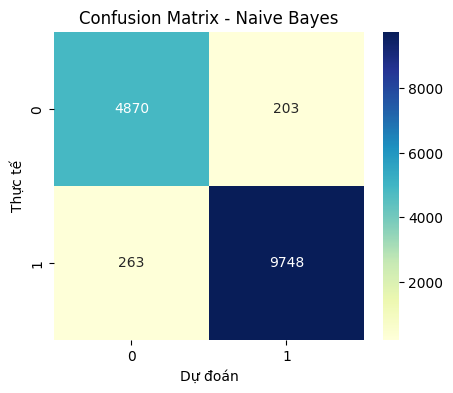


===== KẾT QUẢ MÔ HÌNH: Linear Discriminant Analysis =====
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5073
           1       0.99      1.00      0.99     10011

    accuracy                           0.99     15084
   macro avg       0.99      0.98      0.99     15084
weighted avg       0.99      0.99      0.99     15084



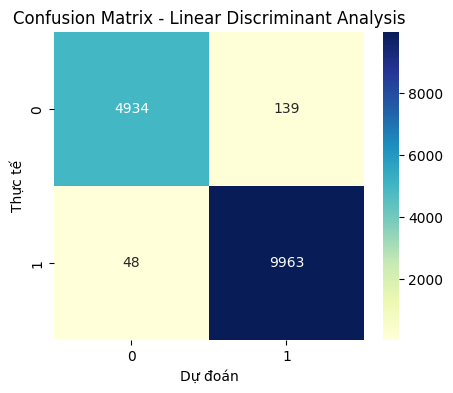

In [ ]:
# --- PHẦN 7: ĐÁNH GIÁ VÀ SO SÁNH ---
def show_results(model, X_input, y_true, model_name):
    y_pred = model.predict(X_input)
    print(f"\n===== KẾT QUẢ MÔ HÌNH: {model_name} =====")
    print(classification_report(y_true, y_pred))

    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()

show_results(best_nb, X_test_tfidf, y_test, "Naive Bayes")
show_results(best_lda, X_test_dense, y_test, "Linear Discriminant Analysis")

In [ ]:
import pickle
from google.colab import files

# 1. Đặt tên file cho các model
nb_filename = 'spam_detector_naive_bayes.pkl'
lda_filename = 'spam_detector_lda.pkl'
tfidf_filename = 'tfidf_vectorizer.pkl' # RẤT QUAN TRỌNG: Phải lưu cả bộ chuyển đổi văn bản

# 2. Lưu model vào ổ đĩa ảo của Colab
# Lưu Naive Bayes
with open(nb_filename, 'wb') as file:
    pickle.dump(best_nb, file)

# Lưu LDA
with open(lda_filename, 'wb') as file:
    pickle.dump(best_lda, file)

# Lưu TF-IDF Vectorizer
# (Bạn cần cái này để khi dùng model ở chỗ khác, nó biết cách chuyển chữ thành số y hệt lúc train)
with open(tfidf_filename, 'wb') as file:
    pickle.dump(tfidf, file)

print("Đã đóng gói xong các model!")

# 3. Lệnh tải file về máy tính cá nhân
files.download(nb_filename)
files.download(lda_filename)
files.download(tfidf_filename)

Đã đóng gói xong các model!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Mounted at /content/drive
Tải các mô hình thành công!

==================== NAIVE BAYES ====================
              precision    recall  f1-score   support

         Ham     1.0000    0.4000    0.5714        10
        Spam     0.6250    1.0000    0.7692        10

    accuracy                         0.7000        20
   macro avg     0.8125    0.7000    0.6703        20
weighted avg     0.8125    0.7000    0.6703        20

Accuracy Score: 0.7000


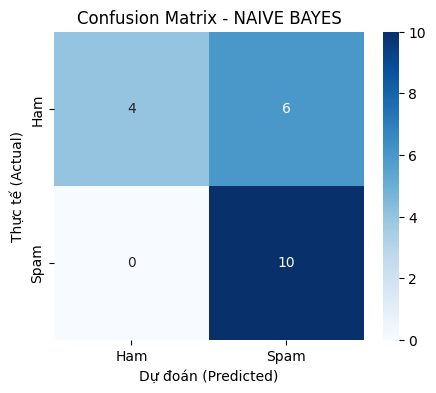


==================== LDA ====================
              precision    recall  f1-score   support

         Ham     1.0000    0.1000    0.1818        10
        Spam     0.5263    1.0000    0.6897        10

    accuracy                         0.5500        20
   macro avg     0.7632    0.5500    0.4357        20
weighted avg     0.7632    0.5500    0.4357        20

Accuracy Score: 0.5500


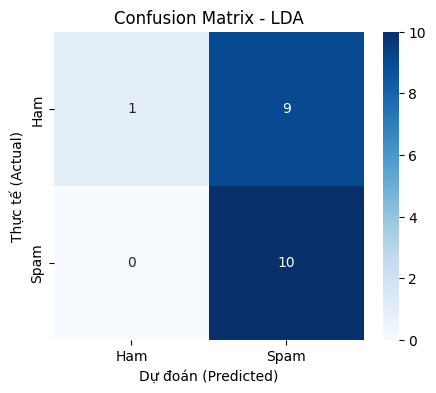

In [ ]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import drive

# 1. Kết nối Google Drive
drive.mount('/content/drive')

# --- THAY ĐỔI ĐƯỜNG DẪN Ở ĐÂY ---
MODEL_PATH = '/content/drive/MyDrive/Models/'

# 2. Tải các model và vectorizer
try:
    tfidf = joblib.load(MODEL_PATH + 'tfidf_vectorizer.pkl')
    nb_model = joblib.load(MODEL_PATH + 'spam_detector_naive_bayes.pkl')
    lda_model = joblib.load(MODEL_PATH + 'spam_detector_lda.pkl')
    print("Tải các mô hình thành công!")
except Exception as e:
    print(f"Lỗi khi tải file: {e}. Vui lòng kiểm tra lại đường dẫn MODEL_PATH.")

# 3. Tạo 20 dữ liệu mẫu (10 Ham, 10 Spam)
data = {
    'email_content': [
        # HAM (0)
        "Hey, are we still meeting for coffee at 5 PM today?",
        "Please find the attached report for the quarterly review.",
        "Can you send me the link for the Zoom meeting tomorrow morning?",
        "I'm running a bit late, see you in 10 minutes.",
        "Don't forget to pick up some milk on your way home.",
        "Thanks for the help with the project, I really appreciate it.",
        "Happy birthday! Hope you have a fantastic day today.",
        "The professor moved the deadline to next Friday.",
        "Is the gym open on Sundays? I'm planning to go.",
        "Let me know if you need anything from the grocery store.",

        # SPAM (1)
        "CONGRATULATIONS! You've won a $1000 Walmart gift card. Click here!",
        "Urgent: Your bank account has been suspended. Verify your identity now.",
        "Get cheap pharmacy online. No prescription needed for Meds!",
        "Work from home and earn $5000 per week. Easy money!",
        "Final notice: Your insurance policy is about to expire. Call us.",
        "Hot singles in your area are waiting for you! Join now.",
        "You have a pending inheritance of $5 million. Contact us immediately.",
        "Lose 20 pounds in 2 weeks with this secret supplement!",
        "REVISE: Your crypto wallet requires an immediate security update.",
        "Double your investment in just 24 hours. Guaranteed returns!"
    ],
    'label': [0,0,0,0,0,0,0,0,0,0, 1,1,1,1,1,1,1,1,1,1]
}

df_test = pd.DataFrame(data)

# 4. Tiền xử lý dữ liệu (Vector hóa)
X_test = tfidf.transform(df_test['email_content'])
y_true = df_test['label']

def evaluate_model(model, name, X, y):
    y_pred = model.predict(X)

    # Nếu là LDA, đôi khi kết quả trả về dạng mảng cần chuyển đổi
    if hasattr(y_pred, "toarray"):
        y_pred = y_pred.toarray()

    print(f"\n" + "="*20 + f" {name} " + "="*20)

    # In chỉ số (không làm tròn quá nhiều)
    print(classification_report(y, y_pred, target_names=['Ham', 'Spam'], digits=4))
    print(f"Accuracy Score: {accuracy_score(y, y_pred):.4f}")

    # Vẽ Ma trận nhầm lẫn
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# 5. Thực thi kiểm thử
evaluate_model(nb_model, "NAIVE BAYES", X_test, y_true)
evaluate_model(lda_model, "LDA", X_test, y_true)

Tải các mô hình thành công!

==================== KẾT QUẢ: NAIVE BAYES ====================
              precision    recall  f1-score   support

         Ham     0.5000    0.1000    0.1667        10
        Spam     0.5000    0.9000    0.6429        10

    accuracy                         0.5000        20
   macro avg     0.5000    0.5000    0.4048        20
weighted avg     0.5000    0.5000    0.4048        20

Accuracy Score: 0.5000


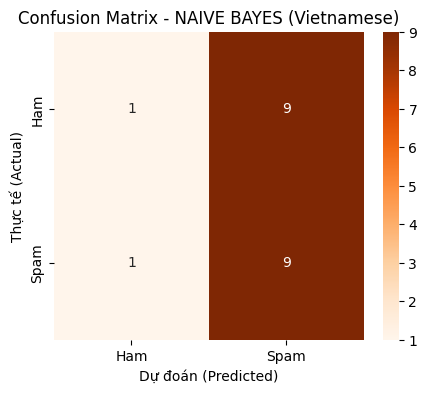


==================== KẾT QUẢ: LDA ====================
              precision    recall  f1-score   support

         Ham     0.0000    0.0000    0.0000        10
        Spam     0.5000    1.0000    0.6667        10

    accuracy                         0.5000        20
   macro avg     0.2500    0.5000    0.3333        20
weighted avg     0.2500    0.5000    0.3333        20

Accuracy Score: 0.5000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


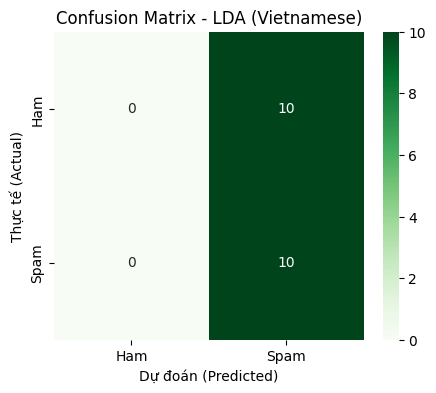

In [ ]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import drive

# # 1. Kết nối Google Drive
# drive.mount('/content/drive')

# # --- THAY ĐỔI ĐƯỜNG DẪN Ở ĐÂY ---
# MODEL_PATH = '/content/drive/MyDrive/Models/'

# 2. Tải các model và vectorizer
try:
    tfidf = joblib.load(MODEL_PATH + 'tfidf_vectorizer.pkl')
    nb_model = joblib.load(MODEL_PATH + 'spam_detector_naive_bayes.pkl')
    lda_model = joblib.load(MODEL_PATH + 'spam_detector_lda.pkl')
    print("Tải các mô hình thành công!")
except Exception as e:
    print(f"Lỗi khi tải file: {e}. Vui lòng kiểm tra lại đường dẫn.")

# 3. Tạo 20 dữ liệu mẫu Tiếng Việt (10 Ham, 10 Spam)
vietnamese_data = {
    'email_content': [
        # HAM (0) - Thư bình thường
        "Chào bạn, tối nay mình đi ăn lúc 7 giờ ở quán cũ nhé.",
        "Gửi em tài liệu báo cáo doanh số tháng này để chuẩn bị họp.",
        "Xác nhận lịch hẹn phỏng vấn ứng viên vào sáng mai lúc 9h.",
        "Con nhớ mua thêm sữa và ít trái cây trên đường đi học về nhé.",
        "Cảm ơn bạn rất nhiều vì đã hỗ trợ mình hoàn thành đồ án này.",
        "Bố mẹ dặn cuối tuần này cả nhà mình về quê thăm ông bà.",
        "Lớp chúng ta sẽ tổ chức đi dã ngoại vào chủ nhật tuần tới.",
        "Bạn đã xem file thiết kế mình gửi qua Zalo chưa? Cho mình xin ý kiến.",
        "Nhắc bạn nhớ nộp bài tập đúng hạn trên hệ thống của trường.",
        "Tối nay có trận bóng hay lắm, qua nhà mình xem cùng cho vui.",

        # SPAM (1) - Thư rác
        "CHÚC MỪNG! Số điện thoại của bạn đã trúng thưởng 50 triệu đồng. Nhận giải ngay!",
        "Cơ hội việc làm tại nhà, thu nhập 10 triệu/tuần không cần kinh nghiệm.",
        "Cảnh báo: Tài khoản ngân hàng của bạn bị tạm khóa. Nhấn vào đây để mở.",
        "Vay tiền nhanh không thế chấp, lãi suất 0%. Đăng ký chỉ cần CCCD.",
        "Dịch vụ tăng tương tác Fanpage, cam kết người dùng thật giá rẻ nhất.",
        "Mua ngay thuốc giảm cân siêu tốc, giảm 5kg chỉ trong 1 tuần!",
        "Thông báo: Bạn có một bưu phẩm chưa nhận từ bưu điện. Gọi lại để biết thêm.",
        "Đầu tư tiền ảo cam kết lợi nhuận 100% mỗi ngày. Tham gia nhóm ngay.",
        "Nhận quà tặng tri ân khách hàng trị giá 2 triệu đồng. Click để lấy mã.",
        "Hỗ trợ nợ xấu, duyệt hồ sơ trong 30 phút. Liên hệ ngay hôm nay!"
    ],
    'label': [0,0,0,0,0,0,0,0,0,0, 1,1,1,1,1,1,1,1,1,1]
}

df_test_vn = pd.DataFrame(vietnamese_data)

# 4. Tiền xử lý dữ liệu
X_test_vn = tfidf.transform(df_test_vn['email_content'])
y_true_vn = df_test_vn['label']

def evaluate_model(model, name, X, y):
    y_pred = model.predict(X)

    # Một số trường hợp LDA trả về mảng thưa
    if hasattr(y_pred, "toarray"):
        y_pred = y_pred.toarray()

    print(f"\n" + "="*20 + f" KẾT QUẢ: {name} " + "="*20)

    # In báo cáo chi tiết
    print(classification_report(y, y_pred, target_names=['Ham', 'Spam'], digits=4))
    print(f"Accuracy Score: {accuracy_score(y, y_pred):.4f}")

    # Vẽ Ma trận nhầm lẫn
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens' if name == "LDA" else 'Oranges',
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.title(f'Confusion Matrix - {name} (Vietnamese)')
    plt.show()

# 5. Thực thi kiểm thử
evaluate_model(nb_model, "NAIVE BAYES", X_test_vn, y_true_vn)
evaluate_model(lda_model, "LDA", X_test_vn, y_true_vn)